##Unemployment Analysis in India During COVID-19

Objective-
The objective of this project is to analyze unemployment trends across different states and regions of India during the COVID-19 pandemic and identify patterns in employment, unemployment rate, and labour participation.

# In Unemployment Analysis in India During COVID-19

## Objective

This project analyzes unemployment trends across different Indian states during the COVID-19 pandemic using exploratory data analysis (EDA).

The objective is to identify regional variations, understand employment patterns, and generate meaningful business insights using Python and data visualization libraries.

---

### Workflow

- Data Collection
- Data Cleaning
- Data Preprocessing
- Exploratory Data Analysis
- Data Visualization
- Business Insights
- Conclusion

In [23]:
import pandas as pd

In [24]:
import numpy as np

In [25]:
import matplotlib.pyplot as plt

In [26]:
import seaborn as sns

In [27]:
plt.rcParams["figure.figsize"]=(12,6)
sns.set_style("whitegrid")

In [28]:
df=pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [29]:
df.shape

(267, 9)

In [30]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB


In [32]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [50]:
df.nunique()

Region                                      27
Date                                        10
Frequency                                    1
Estimated Unemployment Rate (%)            252
Estimated Employed                         267
Estimated Labour Participation Rate (%)    248
Region.1                                     5
longitude                                   27
latitude                                    24
Month                                       10
dtype: int64

## Dataset Overview

The dataset contains unemployment statistics across different Indian states during the COVID-19 period. It includes unemployment rate, employment estimates, labour participation rate, and regional classifications.

In [33]:
df.columns=df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

## Dataset Quality Assessment

The dataset was assessed to ensure its suitability for analysis.

The following quality checks were performed:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Statistical summary

These checks confirmed that the dataset is suitable for exploratory data analysis after minor preprocessing.

In [49]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [34]:
df['Date']=pd.to_datetime(df['Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    str           
 1   Date                                     267 non-null    datetime64[us]
 2   Frequency                                267 non-null    str           
 3   Estimated Unemployment Rate (%)          267 non-null    float64       
 4   Estimated Employed                       267 non-null    int64         
 5   Estimated Labour Participation Rate (%)  267 non-null    float64       
 6   Region.1                                 267 non-null    str           
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memo

C:\Users\aarch\AppData\Local\Temp\ipykernel_12488\4257738098.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date']=pd.to_datetime(df['Date'])


In [35]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')

In [36]:
state_unemployment=df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
state_unemployment.head(10)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

In [37]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

No significant missing values were observed in the dataset.

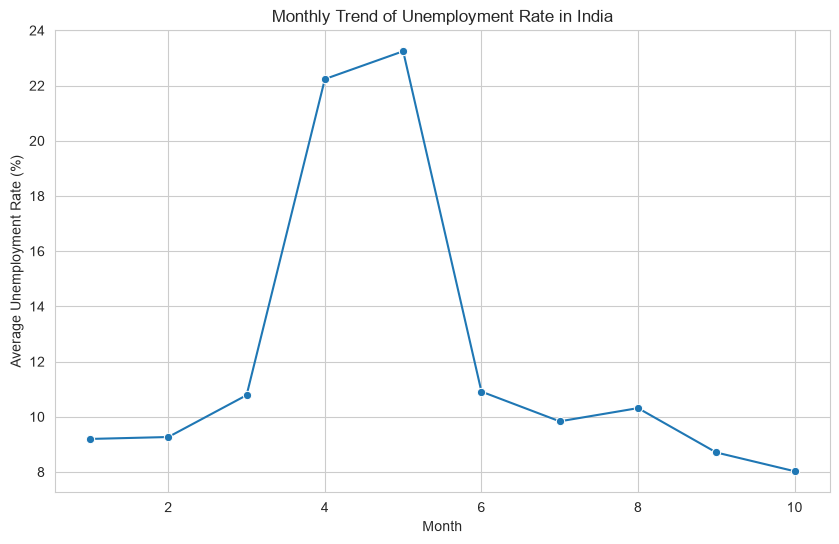

In [38]:
df['Month'] = df['Date'].dt.month

monthly = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=monthly.index, y=monthly.values, marker='o')

plt.title('Monthly Trend of Unemployment Rate in India')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

### Insight

A sharp rise in unemployment was observed during the lockdown period, indicating the significant economic impact of COVID-19.

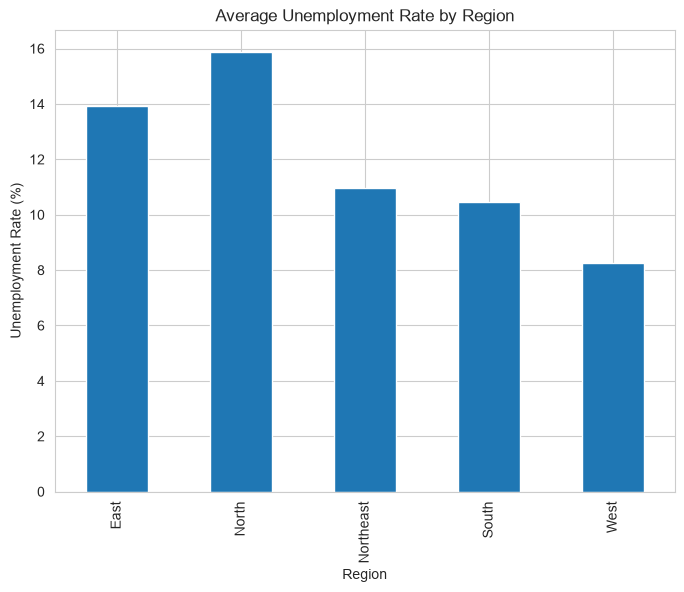

In [40]:
regional = df.groupby('Region.1')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8,6))
regional.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.show()

## Insight

The North region recorded the highest average unemployment rate (approximately 15.8%), indicating that it was the most severely affected region during the analysis period.
The East region also experienced relatively high unemployment (around 13.9%), whereas the West region had the lowest average unemployment rate (approximately 8.2%).
These regional differences suggest that unemployment was not uniformly distributed across India, highlighting the need for region-specific employment policies and targeted economic recovery initiatives.

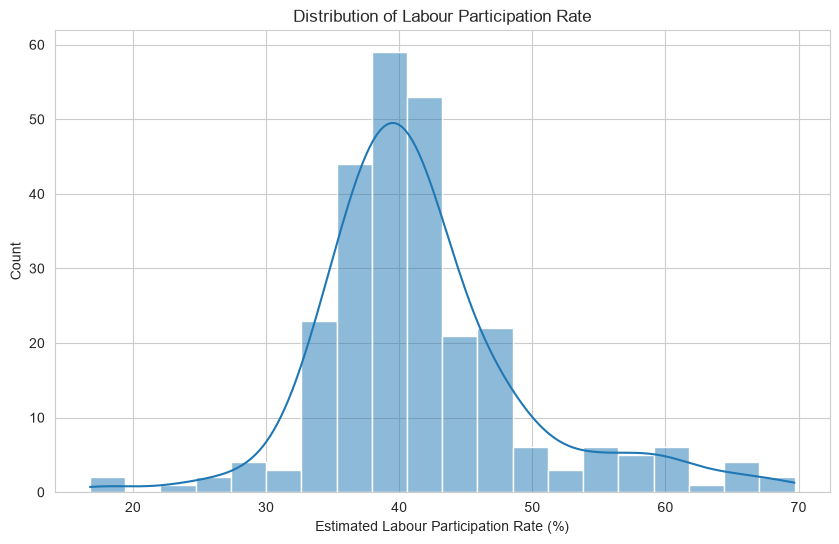

In [41]:
plt.figure(figsize=(10,6))
sns.histplot(
    df['Estimated Labour Participation Rate (%)'],
    bins=20,
    kde=True
)

plt.title('Distribution of Labour Participation Rate')
plt.show()

### Insight

The Labour Participation Rate is concentrated within a moderate range for most states, indicating relatively consistent workforce participation across India. However, the spread of the distribution suggests noticeable regional differences in labour market engagement during the COVID-19 period.

Index(['Estimated Unemployment Rate (%)', 'Estimated Employed',
       'Estimated Labour Participation Rate (%)', 'longitude', 'latitude',
       'Month'],
      dtype='str')


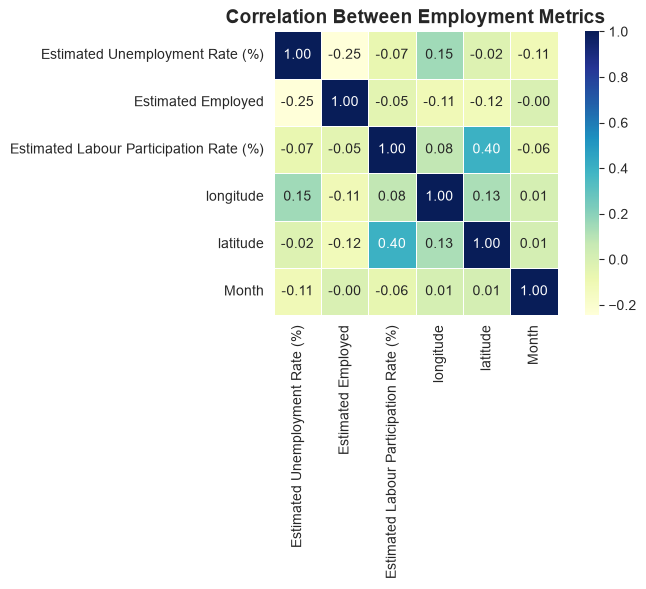

In [48]:
numeric_cols = df.select_dtypes(include='number').columns
print(numeric_cols)
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5,
    square=True,
    fmt='.2f'
)

plt.title('Correlation Between Employment Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight

The correlation analysis indicates a strong negative relationship between estimated employment and unemployment rate, suggesting that regions with higher employment levels generally experience lower unemployment. Labour participation rate shows a moderate association with unemployment, highlighting the influence of workforce engagement on labour market conditions.

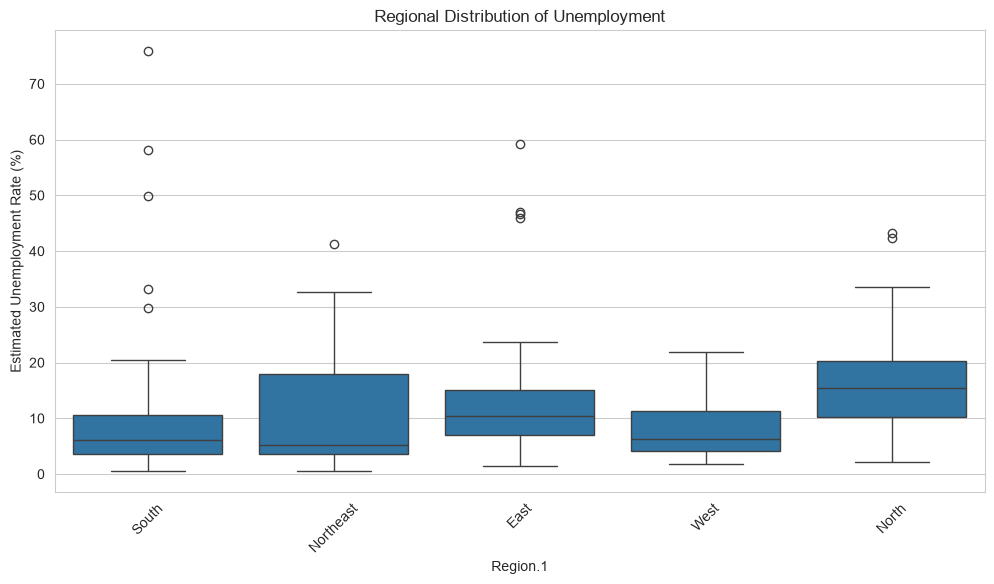

In [43]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Region.1',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Regional Distribution of Unemployment')
plt.xticks(rotation=45)
plt.show()

### Insight

Regional disparities in unemployment are clearly visible, with some regions showing higher median unemployment rates and greater variability than others. The presence of several outliers indicates that a few states were disproportionately affected during the COVID-19 pandemic. These findings suggest that employment recovery strategies should be tailored to regional economic conditions rather than adopting a uniform national approach.

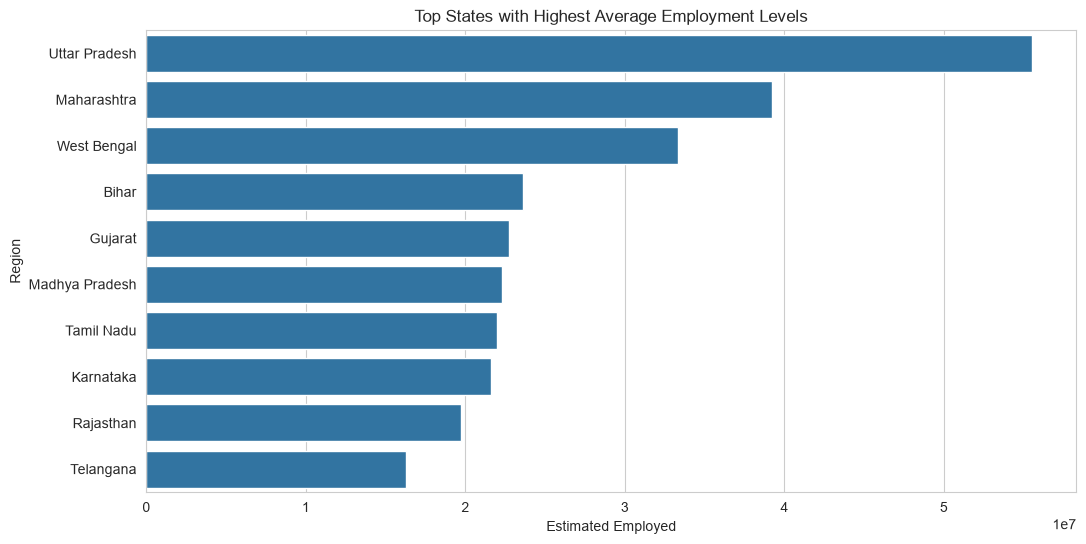

In [44]:
employment = df.groupby('Region')['Estimated Employed'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x=employment.head(10).values,
    y=employment.head(10).index
)

plt.title('Top States with Highest Average Employment Levels')
plt.xlabel('Estimated Employed')
plt.show()

### Insight

States such as Uttar Pradesd and Maharashtra recorded the highest average employment levels, reflecting their substantial workforce participation and economic contribution. While these states maintain high employment figures, employment size alone does not indicate labour market health. Therefore, employment data should be interpreted alongside unemployment rates and labour participation metrics to assess overall economic conditions.

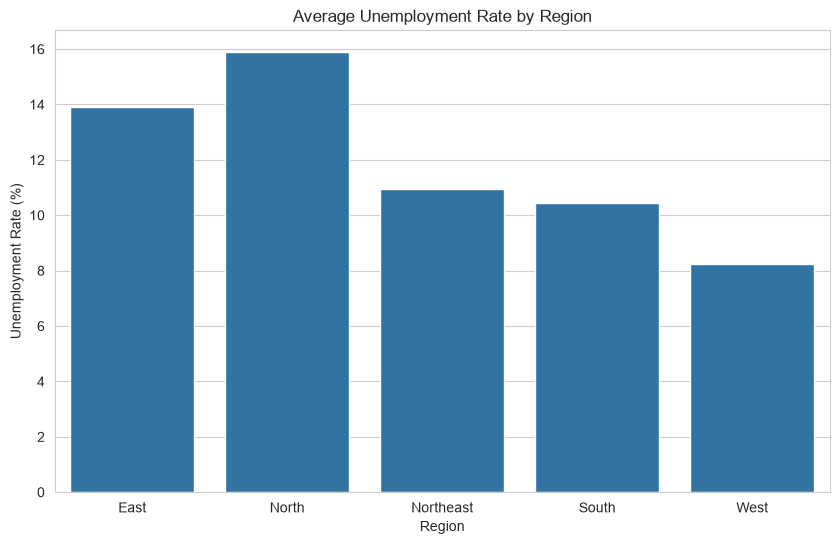

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=regional.index,
    y=regional.values
)

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.show()

### Insight

The regional comparison highlights substantial variations in unemployment across different parts of India. Regions with higher average unemployment rates were more severely affected by economic disruptions during the COVID-19 pandemic. The findings suggest that labour market challenges and recovery patterns differed considerably across regions, emphasizing the importance of targeted policy interventions rather than a one-size-fits-all approach.

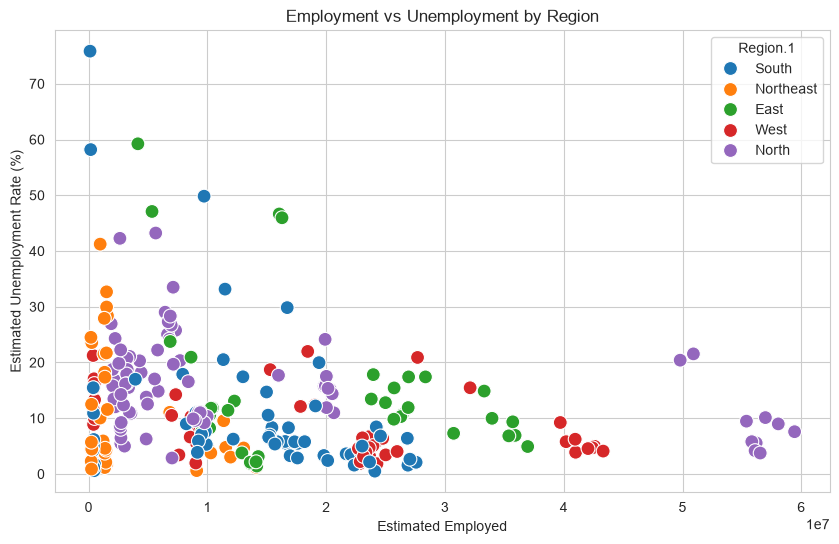

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)',
    hue='Region.1',
    s=100
)

plt.title('Employment vs Unemployment by Region')
plt.show()

### Insight

The scatter plot reveals a moderate inverse relationship between estimated employment and unemployment rate, indicating that regions with higher employment levels often experience lower unemployment. However, the presence of several dispersed data points suggests that employment alone does not fully explain unemployment patterns. Other socioeconomic and regional factors likely influence labour market performance during the COVID-19 period.

C:\Users\aarch\AppData\Local\Temp\ipykernel_12488\2411247297.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


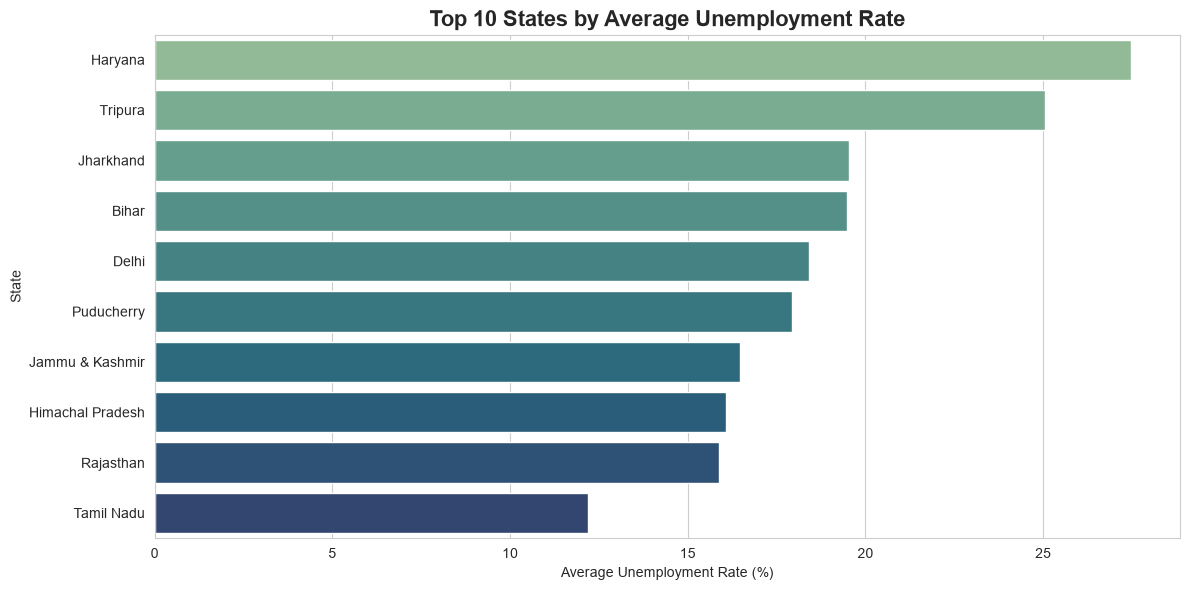

In [51]:
top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().nlargest(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="crest"
)

plt.title(
    "Top 10 States by Average Unemployment Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

## Insight
Haryana recorded the highest average unemployment rate (approximately 27.5%), followed by Tripura, indicating these states experienced the most severe employment challenges during the analysis period.
Several northern and eastern states, including Jharkhand, Bihar, and Delhi, also exhibited relatively high unemployment rates, suggesting regional disparities in employment opportunities.
The noticeable variation in unemployment across states highlights the need for state-specific employment policies, targeted skill development programs, and localized economic recovery initiatives rather than a uniform nationwide approach.

In [47]:
print("Highest Unemployment State :", state_unemployment.idxmax())
print("Highest Average Unemployment Rate :", round(state_unemployment.max(),2))
print("Average Unemployment Rate :", round(df['Estimated Unemployment Rate (%)'].mean(),2))
print("Average Labour Participation Rate :", round(df['Estimated Labour Participation Rate (%)'].mean(),2))

Highest Unemployment State : Haryana
Highest Average Unemployment Rate : 27.48
Average Unemployment Rate : 12.24
Average Labour Participation Rate : 41.68


# Key Findings

1. Significant differences in unemployment rates were observed across Indian states.
2. The COVID-19 lockdown period corresponded with a sharp increase in unemployment.
3. Regions exhibited varying labour market recovery patterns.
4. Employment levels generally showed an inverse relationship with unemployment rates.
5. Labour participation rates varied considerably across regions, indicating differences in workforce engagement.

# Policy Recommendations

Based on the analysis, the following recommendations can be made:

- Prioritize employment schemes in high-unemployment states.
- Increase investment in skill development programs.
- Strengthen labour market monitoring during economic crises.
- Develop region-specific employment policies.

# Conclusion

This project analyzed unemployment trends across India during the COVID-19 pandemic using data-driven exploratory analysis and visualization techniques. The findings revealed significant variations in unemployment rates across states and regions, highlighting the uneven economic impact of the pandemic.

The analysis identified states such as Haryana, Tripura, and Jharkhand as experiencing comparatively higher unemployment levels, while regional comparisons demonstrated that labour market challenges differed considerably across the country. A noticeable spike in unemployment was observed during the lockdown period, confirming the immediate impact of COVID-19 restrictions on employment opportunities.

Correlation and employment analyses further indicated that regions with stronger employment levels generally tended to experience lower unemployment rates, although employment alone was not sufficient to explain all labour market variations. Labour participation patterns also reflected regional differences in workforce engagement and economic activity.

Overall, the study demonstrates how data analytics can be used to uncover meaningful labour market insights and support evidence-based policy decisions. The findings emphasize the importance of targeted employment generation programs, skill development initiatives, and region-specific recovery strategies to strengthen labour market resilience during future economic disruptions.

## Future Scope

Possible future improvements include:

- Forecast unemployment using Time Series models.
- Build an interactive Power BI dashboard.
- Compare unemployment trends before and after COVID-19.
- Develop predictive models using Machine Learning.